# Tutorial 7: Public SWMM Network BME with Simulated Gauges

This notebook builds a fully shareable network-domain BME example from the public KBWI SWMM model.

The workflow mirrors the private sewer example, but adapts to the structure of this public model:

1. Load the public KBWI SWMM model and identify the largest rainfall event in the forcing record.
2. Use SWMM subcatchment runoff mapped to outlet nodes as the **soft data** signal.
3. Simulate sparse hard observations by shifting and perturbing the SWMM signal in a structured way.
4. Run space-time network BME with hard-only and hard-plus-soft configurations.
5. Compare posterior mean and uncertainty against the synthetic observed truth.

> Note: this public model uses `IGNORE_ROUTING YES`, so link and node hydraulic responses are essentially inactive in the saved output. The informative public signal is the runoff generated by the two subcatchments, which we map to their outlet nodes.

In [2]:
from __future__ import annotations

import os
import re
from bisect import bisect_left
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from epaswmm import output as epa_out
from swmm_bridge import get_output_reader

from pybme.network import NetworkCovariance, NetworkCovarianceST, adjacency_from_edges
from pybme.network_plots import plot_network_observations
from pybme.predict import bme_predict_network_st
from pybme.soft_data import SoftPDF
from pybme.swmm import build_edge_array, parse_swmm_inp

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

RNG = np.random.default_rng(42)

In [3]:
def resolve_model_dir() -> Path:
    candidates = []
    env_dir = os.environ.get('PYBME_PUBLIC_SWMM_DIR')
    if env_dir:
        candidates.append(Path(env_dir))
    candidates.extend([
        Path(r'C:/Users/wiesnec/Downloads/KBWI_Balance_1948-2011_sw52'),
        Path.cwd() / 'KBWI_Balance_1948-2011_sw52',
        Path.cwd().parent / 'external_data' / 'KBWI_Balance_1948-2011_sw52',
    ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        'Could not find the public KBWI SWMM model. Set PYBME_PUBLIC_SWMM_DIR '
        'or update the candidate paths in resolve_model_dir().'
    )


def read_subcatchment_outlets(inp_path: Path) -> dict[str, str]:
    lines = inp_path.read_text(errors='replace').splitlines()
    in_section = False
    outlets: dict[str, str] = {}
    for line in lines:
        text = line.strip()
        if text.startswith('['):
            in_section = text.upper() == '[SUBCATCHMENTS]'
            continue
        if not in_section or not text or text.startswith(';'):
            continue
        parts = text.split()
        outlets[parts[0]] = parts[2]
    return outlets


def top_rain_event(rain_path: Path) -> tuple[float, datetime]:
    best: tuple[float, datetime] | None = None
    for line in rain_path.read_text(errors='replace').splitlines()[2:]:
        match = re.search(r'(\d{8} \d{2}:\d{2})\s+([0-9.]+)\s', line)
        if not match:
            continue
        rain = float(match.group(2))
        if rain >= 900:
            continue
        timestamp = datetime.strptime(match.group(1), '%Y%m%d %H:%M')
        candidate = (rain, timestamp)
        if best is None or candidate > best:
            best = candidate
    if best is None:
        raise RuntimeError('No valid rainfall events were found in the hourly precipitation file.')
    return best


def extract_public_event_dataset(model_dir: Path, step_minutes: int = 60, runoff_threshold: float = 2e-3):
    inp_path = model_dir / 'KBWI_Balance_1948-2011.inp'
    out_path = model_dir / 'KBWI_Balance_1948-2011.out'
    rain_path = model_dir / 'BaltimoreMD_HourlyHPCP_Aug1948-Aug2011.txt'

    network = parse_swmm_inp(inp_path)
    subcatchment_outlets = read_subcatchment_outlets(inp_path)
    reader = get_output_reader(str(out_path))
    peak_rain, event_dt = top_rain_event(rain_path)

    start_idx = bisect_left(reader.times, event_dt - timedelta(hours=4))
    end_idx = bisect_left(reader.times, event_dt + timedelta(hours=12))
    stride = max(1, step_minutes // 5)

    node_names = network.all_node_names
    node_index = {name: i for i, name in enumerate(node_names)}
    time_values = []
    runoff_by_node = {name: [] for name in node_names}
    rain_series = []

    for time_idx in range(start_idx, end_idx, stride):
        runoff = reader.get_subcatchment_values_by_time_and_attribute(
            time_idx, epa_out.SubcatchAttribute.RUNOFF_RATE
        )
        groundwater = reader.get_subcatchment_values_by_time_and_attribute(
            time_idx, epa_out.SubcatchAttribute.GROUNDWATER_OUTFLOW
        )
        rainfall = reader.get_subcatchment_values_by_time_and_attribute(
            time_idx, epa_out.SubcatchAttribute.RAINFALL
        )

        node_values = {name: 0.0 for name in node_names}
        for subcatchment, outlet in subcatchment_outlets.items():
            node_values[outlet] += float(runoff.get(subcatchment, 0.0))
            node_values[outlet] += float(groundwater.get(subcatchment, 0.0))

        if max(node_values.values()) <= runoff_threshold:
            continue

        time_values.append(reader.times[time_idx])
        rain_series.append(max(float(v) for v in rainfall.values()))
        for name in node_names:
            runoff_by_node[name].append(node_values[name])

    active_nodes = [
        name for name, values in runoff_by_node.items() if np.max(values or [0.0]) > 1e-8
    ]
    times = np.array(time_values)
    times_h = np.array([(dt - times[0]).total_seconds() / 3600.0 for dt in times])

    return {
        'model_dir': model_dir,
        'network': network,
        'node_names': node_names,
        'node_index': node_index,
        'active_nodes': active_nodes,
        'event_dt': event_dt,
        'peak_rain': peak_rain,
        'times': times,
        'times_h': times_h,
        'rain': np.array(rain_series, dtype=float),
        'runoff_by_node': {name: np.array(values, dtype=float) for name, values in runoff_by_node.items()},
    }


def simulate_observed_truth(dataset: dict, seed: int = 42):
    rng = np.random.default_rng(seed)
    truth_by_node = {}
    residual_sd_by_node = {}

    for idx, node_name in enumerate(dataset['active_nodes']):
        swmm_series = dataset['runoff_by_node'][node_name]
        phase = np.linspace(0.0, np.pi, len(swmm_series))
        rel_bias = -0.10 if idx % 2 == 0 else 0.12
        abs_shift = 0.01 if idx % 2 == 0 else -0.005
        noise_sd = 0.015 + 0.10 * np.sqrt(np.maximum(swmm_series, 0.0) + 1e-4)
        truth = np.maximum(
            0.0,
            swmm_series * (1.0 + rel_bias + 0.06 * np.sin(phase))
            + abs_shift
            + rng.normal(0.0, noise_sd),
        )
        truth_by_node[node_name] = truth
        residual_sd_by_node[node_name] = float(np.std(truth - swmm_series))

    return truth_by_node, residual_sd_by_node


def build_bme_inputs(dataset: dict, truth_by_node: dict[str, np.ndarray], residual_sd_by_node: dict[str, float], hard_stride: int = 2):
    node_index = dataset['node_index']
    times_h = dataset['times_h']

    ch_nodes = []
    th = []
    zh = []
    cs_nodes = []
    ts = []
    soft_pdfs = []

    for node_name in dataset['active_nodes']:
        sigma = max(residual_sd_by_node[node_name], 0.03)
        truth = truth_by_node[node_name]
        soft_mean = dataset['runoff_by_node'][node_name]

        for j, value in enumerate(truth):
            if j % hard_stride == 0:
                ch_nodes.append(node_index[node_name])
                th.append(float(times_h[j]))
                zh.append(float(value))

        for j, mu in enumerate(soft_mean):
            cs_nodes.append(node_index[node_name])
            ts.append(float(times_h[j]))
            soft_pdfs.append(SoftPDF.from_truncnorm(mu=float(mu), sigma=float(sigma), a=0.0, b=None))

    return {
        'ch_nodes': np.array(ch_nodes, dtype=int),
        'th': np.array(th, dtype=float),
        'zh': np.array(zh, dtype=float),
        'cs_nodes': np.array(cs_nodes, dtype=int),
        'ts': np.array(ts, dtype=float),
        'soft_pdfs': soft_pdfs,
    }

In [4]:
model_dir = resolve_model_dir()
dataset = extract_public_event_dataset(model_dir, step_minutes=60)
truth_by_node, residual_sd_by_node = simulate_observed_truth(dataset, seed=42)
inputs = build_bme_inputs(dataset, truth_by_node, residual_sd_by_node, hard_stride=2)

print(f"Public model directory: {model_dir}")
print(f"Largest hourly rainfall event: {dataset['peak_rain']:.2f} in/hr at {dataset['event_dt']}")
print(f"Network nodes: {len(dataset['node_names'])}, active outlet nodes: {dataset['active_nodes']}")
print(f"Event time steps retained: {len(dataset['times'])}")
print(f"Hard observations used by BME: {len(inputs['zh'])}")
print(f"Soft PDFs used by BME: {len(inputs['soft_pdfs'])}")
print({node: round(sd, 4) for node, sd in residual_sd_by_node.items()})

Public model directory: C:\Users\wiesnec\Downloads\KBWI_Balance_1948-2011_sw52
Largest hourly rainfall event: 2.58 in/hr at 1948-08-11 20:00:00
Network nodes: 4, active outlet nodes: ['catchbasin', 'us_culvert']
Event time steps retained: 16
Hard observations used by BME: 16
Soft PDFs used by BME: 32
{'catchbasin': 0.0576, 'us_culvert': 0.0085}


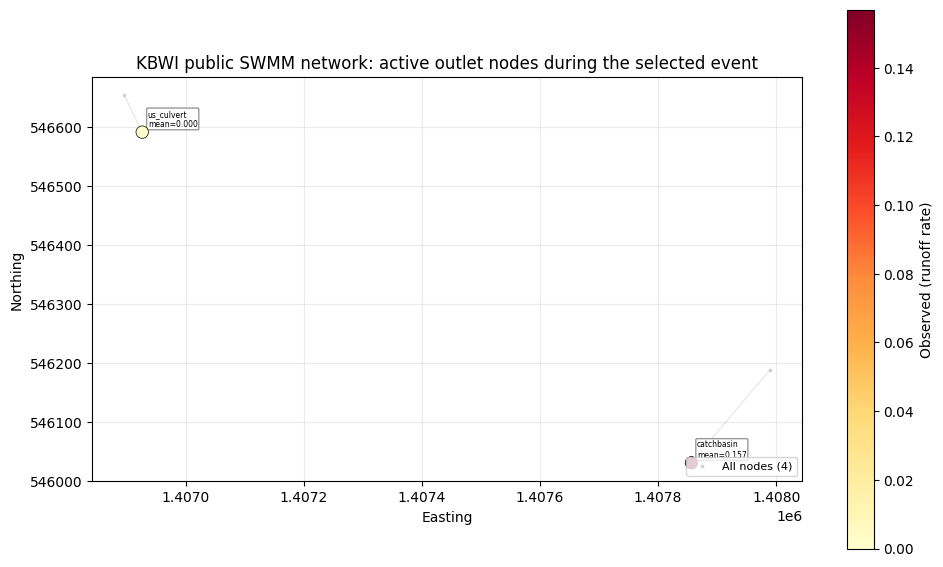

In [5]:
avg_signal = np.array([dataset['runoff_by_node'][name].mean() for name in dataset['node_names']])
active_node_indices = [dataset['node_index'][name] for name in dataset['active_nodes']]
avg_active_signal = np.array([dataset['runoff_by_node'][name].mean() for name in dataset['active_nodes']])
active_labels = [f"{name}\nmean={value:.3f}" for name, value in zip(dataset['active_nodes'], avg_active_signal)]

fig, ax = plot_network_observations(
    dataset['node_names'],
    dataset['network'].coords,
    dataset['network'].edges,
    obs_nodes=active_node_indices,
    obs_values=avg_active_signal,
    obs_labels=active_labels,
    title='KBWI public SWMM network: active outlet nodes during the selected event',
    units='runoff rate',
)
plt.show()

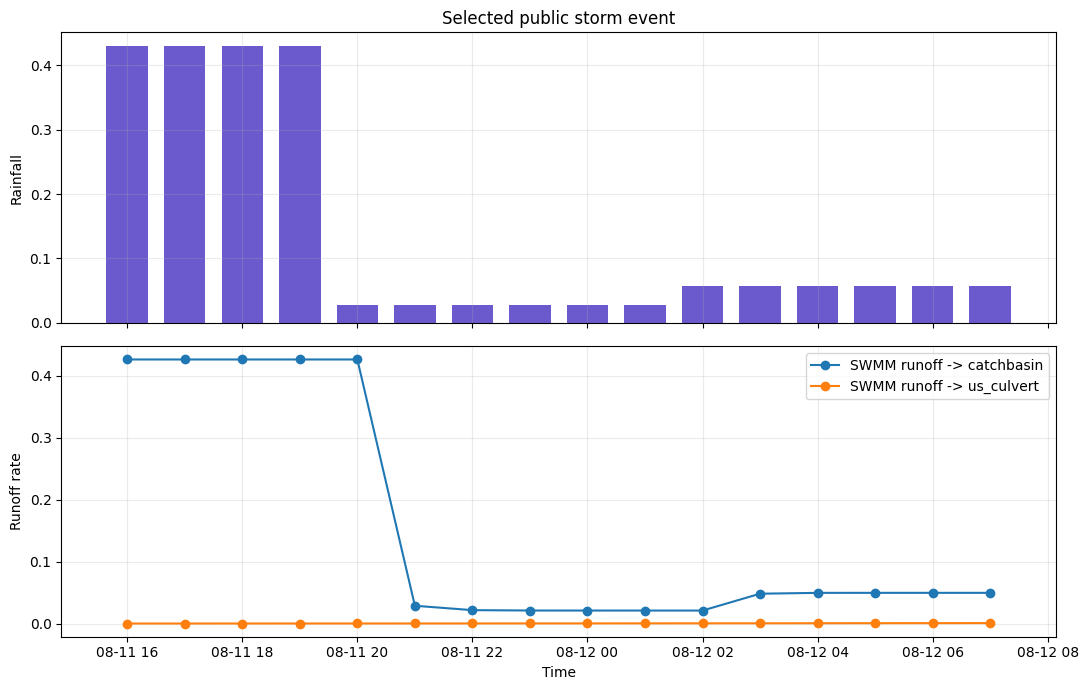

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(dataset['times'], dataset['rain'], width=0.03, color='slateblue')
axes[0].set_ylabel('Rainfall')
axes[0].set_title('Selected public storm event')

for node_name in dataset['active_nodes']:
    axes[1].plot(dataset['times'], dataset['runoff_by_node'][node_name], marker='o', label=f'SWMM runoff -> {node_name}')
axes[1].set_ylabel('Runoff rate')
axes[1].set_xlabel('Time')
axes[1].legend()
plt.tight_layout()
plt.show()

## Simulated hard observations

The synthetic observed truth is intentionally not identical to SWMM. For each active node we apply:

- a persistent multiplicative bias,
- a small additive offset,
- a smooth within-event drift term,
- heteroscedastic random perturbations that grow with runoff magnitude.

Only every second timestep is revealed to BME as hard data. The full synthetic series is kept for evaluation.

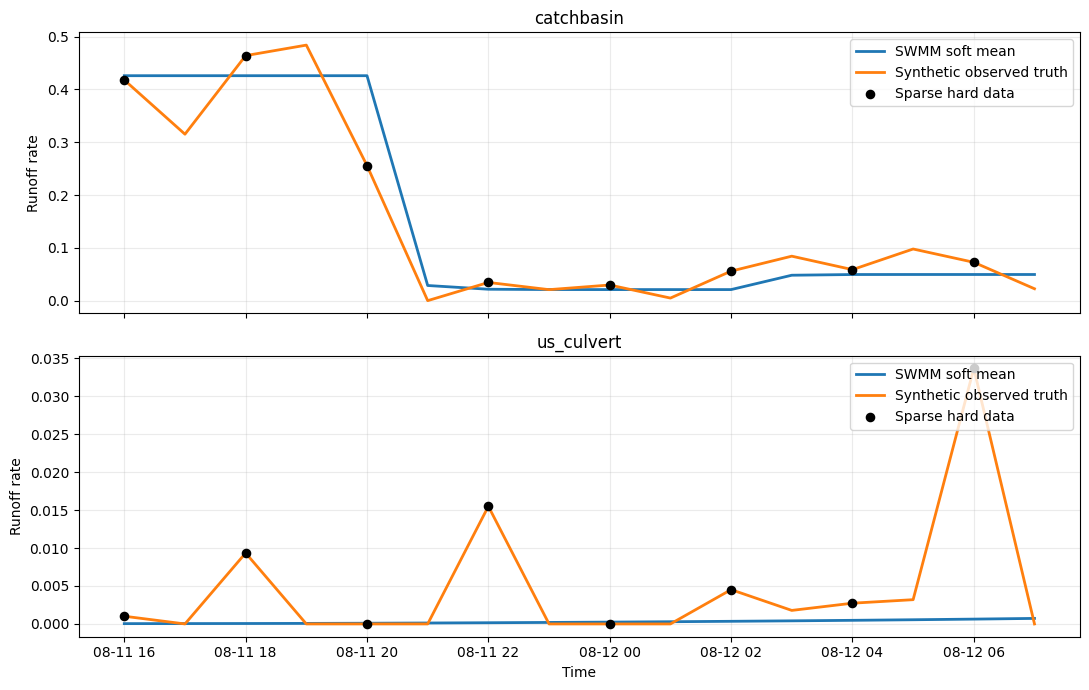

In [7]:
fig, axes = plt.subplots(len(dataset['active_nodes']), 1, figsize=(11, 7), sharex=True)
if len(dataset['active_nodes']) == 1:
    axes = [axes]

for ax, node_name in zip(axes, dataset['active_nodes']):
    truth = truth_by_node[node_name]
    swmm = dataset['runoff_by_node'][node_name]
    hard_mask = np.array([i % 2 == 0 for i in range(len(truth))])
    ax.plot(dataset['times'], swmm, label='SWMM soft mean', color='tab:blue', linewidth=2)
    ax.plot(dataset['times'], truth, label='Synthetic observed truth', color='tab:orange', linewidth=2)
    ax.scatter(dataset['times'][hard_mask], truth[hard_mask], label='Sparse hard data', color='black', s=35, zorder=5)
    ax.set_title(node_name)
    ax.set_ylabel('Runoff rate')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

In [8]:
node_names = dataset['node_names']
active_nodes = dataset['active_nodes']
active_idx = np.array([dataset['node_index'][name] for name in active_nodes], dtype=int)

edge_array = build_edge_array(node_names, dataset['network'].edges)
W = adjacency_from_edges(len(node_names), edge_array)
sp_cov0 = NetworkCovariance(W, kappa=0.35, sigma2=1.0, from_adjacency=True)
sigma2_scale = float(np.var(inputs['zh']) / max(sp_cov0.marginal_variance(np.unique(inputs['ch_nodes'])).mean(), 1e-12))
sp_cov = NetworkCovariance(W, kappa=0.35, sigma2=sigma2_scale, from_adjacency=True)
st_cov = NetworkCovarianceST(sp_cov, model_t='exponential', params_t=[1.0, 4.0], sigma2=sigma2_scale)

ck_nodes = np.repeat(active_idx, len(dataset['times_h']))
tk = np.tile(dataset['times_h'], len(active_nodes))

results_hard_only = bme_predict_network_st(
    ck_nodes=ck_nodes,
    tk=tk,
    ch_nodes=inputs['ch_nodes'],
    th=inputs['th'],
    zh=inputs['zh'],
    net_cov_st=st_cov,
    nhmax=8,
    order=0,
    mean_prior=float(np.mean(inputs['zh'])),
)

results_hard_soft = bme_predict_network_st(
    ck_nodes=ck_nodes,
    tk=tk,
    ch_nodes=inputs['ch_nodes'],
    th=inputs['th'],
    zh=inputs['zh'],
    cs_nodes=inputs['cs_nodes'],
    ts=inputs['ts'],
    soft_pdfs=inputs['soft_pdfs'],
    net_cov_st=st_cov,
    nhmax=8,
    nsmax=4,
    order=0,
    n_grid=80,
    method='laplace',
    mean_prior=float(np.mean(inputs['zh'])),
)

hard_only_mean = np.array([r.mean for r in results_hard_only]).reshape(len(active_nodes), len(dataset['times_h']))
hard_only_std = np.sqrt(np.maximum(np.array([r.variance for r in results_hard_only]), 0.0)).reshape(len(active_nodes), len(dataset['times_h']))
hard_soft_mean = np.array([r.mean for r in results_hard_soft]).reshape(len(active_nodes), len(dataset['times_h']))
hard_soft_std = np.sqrt(np.maximum(np.array([r.variance for r in results_hard_soft]), 0.0)).reshape(len(active_nodes), len(dataset['times_h']))
truth_matrix = np.vstack([truth_by_node[name] for name in active_nodes])

rmse_hard_only = float(np.sqrt(np.mean((hard_only_mean - truth_matrix) ** 2)))
rmse_hard_soft = float(np.sqrt(np.mean((hard_soft_mean - truth_matrix) ** 2)))
avg_std_hard_only = float(np.mean(hard_only_std))
avg_std_hard_soft = float(np.mean(hard_soft_std))

print(f'RMSE hard only:   {rmse_hard_only:.4f}')
print(f'RMSE hard + soft: {rmse_hard_soft:.4f}')
print(f'Average posterior std, hard only:   {avg_std_hard_only:.4f}')
print(f'Average posterior std, hard + soft: {avg_std_hard_soft:.4f}')

    BME ST: 32/32 (100%)    
    BME ST: 30/32 (93%) ...

RMSE hard only:   0.0477
RMSE hard + soft: 0.0362
Average posterior std, hard only:   0.0283
Average posterior std, hard + soft: 0.0133


    BME ST: 32/32 (100%)    


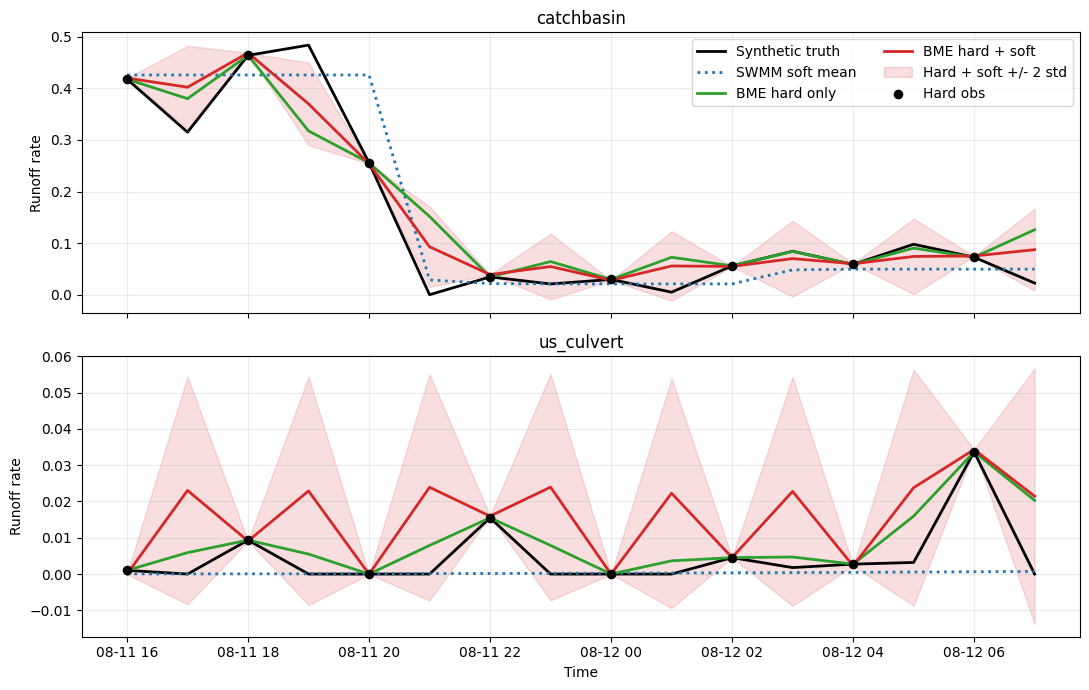

In [9]:
fig, axes = plt.subplots(len(active_nodes), 1, figsize=(11, 7), sharex=True)
if len(active_nodes) == 1:
    axes = [axes]

for row, node_name in enumerate(active_nodes):
    ax = axes[row]
    truth = truth_by_node[node_name]
    swmm = dataset['runoff_by_node'][node_name]
    hard_mask = np.array([i % 2 == 0 for i in range(len(truth))])

    ax.plot(dataset['times'], truth, color='black', linewidth=2, label='Synthetic truth')
    ax.plot(dataset['times'], swmm, color='tab:blue', linestyle=':', linewidth=2, label='SWMM soft mean')
    ax.plot(dataset['times'], hard_only_mean[row], color='tab:green', linewidth=2, label='BME hard only')
    ax.plot(dataset['times'], hard_soft_mean[row], color='tab:red', linewidth=2, label='BME hard + soft')
    ax.fill_between(
        dataset['times'],
        hard_soft_mean[row] - 2 * hard_soft_std[row],
        hard_soft_mean[row] + 2 * hard_soft_std[row],
        color='tab:red',
        alpha=0.15,
        label='Hard + soft +/- 2 std' if row == 0 else None,
    )
    ax.scatter(dataset['times'][hard_mask], truth[hard_mask], color='black', s=35, zorder=5, label='Hard obs' if row == 0 else None)
    ax.set_title(node_name)
    ax.set_ylabel('Runoff rate')

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles, labels, loc='upper right', ncol=2)
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

## Interpretation

This public tutorial uses the same logic as the larger sewer-network example, just on a minimal runoff network. The main takeaways are:

- **Soft data** come from the physics model: here, SWMM runoff mapped to outlet nodes.
- **Hard data** are sparse and imperfect observations: here, a biased and noisy version of the event response sampled every two hours.
- **BME hard + soft** usually tracks the synthetic truth better than hard-only interpolation because it borrows both from the graph covariance and from the SWMM soft PDFs.
- The truncated-normal soft PDFs enforce non-negativity and activate the fast analytic Laplace path.

If you want to adapt this notebook to a richer public SWMM model, the same pattern applies: map model-derived quantities to network nodes, estimate realistic uncertainty for those model outputs, and combine them with sparse hard observations in `bme_predict_network_st`.